In [ ]:
!pip install ucimlrepo
!pip install plotly
!

  Using cached ucimlrepo-0.0.7-py3-none-any.whl.metadata (5.5 kB)
  Using cached pandas-2.3.1-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached certifi-2025.7.14-py3-none-any.whl.metadata (2.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached ucimlrepo-0.0.7-py3-none-any.whl (8.0 kB)
Using cached certifi-2025.7.14-py3-none-any.whl (162 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB 325.1 kB/s eta 0:00:35
   ---------------------------------------- 0.1/11.3 MB 544.7 kB/s eta 0:00:21
   ---------------------------------------- 0.1/11.3 MB 787.7 kB/s eta 0:00:15
    --------------------------------------- 0.2/11.3 MB 1.0 MB/s eta 0:00:11
   - -------------------------------------- 0.3/11.3 MB 1.2 MB/s eta 0:00:10
   - --------------


[notice] A new release of pip is available: 23.3.2 -> 25.1.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.3.2 -> 25.1.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
!pip install scikit-learn

     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     --------------------------------- ------ 51.2/60.8 kB ? eta -:--:--
     ---------------------------------------- 60.8/60.8 kB 1.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.1/8.9 MB 1.3 MB/s eta 0:00:07
   ---------------------------------------- 0.1/8.9 MB 1.3 MB/s eta 0:00:07
   ---------------------------------------- 0.1/8.9 MB 1.3 MB/s eta 0:00:07
   - -------------------------------------- 0.2/8.9 MB 1.5 MB/s eta 0:00:06
   - -------------------------------------- 0.2/8.9 MB 1.5 MB/s eta 0:00:06
   - -------------------------------------- 0.3/8.9 MB 874.6 kB/s eta 0:00:10
   - -------------------------------------- 0.3/8.9 MB 951.8 kB/s eta 0:00:10
   - -------------------------------------- 0.4/8.9 MB 1.0 MB/s eta 0:00:09
   -- ------------------------------------- 0.5/8.9 MB 1.1 MB/s eta 0:00:08
   -- ------------


[notice] A new release of pip is available: 23.3.2 -> 25.1.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [9]:
from ucimlrepo import fetch_ucirepo

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_predict

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

import plotly.express as px

ModuleNotFoundError: No module named 'matplotlib'

In [3]:
# fetch dataset
statlog_german_credit_data = fetch_ucirepo(id=144)

X = statlog_german_credit_data.data.features
y = statlog_german_credit_data.data.targets

statlog_german_credit_data.metadata

statlog_german_credit_data.variables


,name,role,type,demographic,description,units,missing_values
0,Attribute1,Feature,Categorical,None,Status of existing checking account,None,no
1,Attribute2,Feature,Integer,None,Duration,months,no
2,Attribute3,Feature,Categorical,None,Credit history,None,no
3,Attribute4,Feature,Categorical,None,Purpose,None,no
4,Attribute5,Feature,Integer,None,Credit amount,None,no
5,Attribute6,Feature,Categorical,None,Savings account/bonds,None,no
6,Attribute7,Feature,Categorical,Other,Present employment since,None,no
7,Attribute8,Feature,Integer,None,Installment rate in percentage of disposable i...,None,no
8,Attribute9,Feature,Categorical,Marital Status,Personal status and sex,None,no
9,Attribute10,Feature,Categorical,None,Other debtors / guarantors,None,no


In [4]:
#checking data imbalance
y.value_counts()

class
1        700
2        300
Name: count, dtype: int64

## Data Preprocessing

- Renaming the columns
- Renaming categorical columns values

In [5]:
#renaming the columns
features = [
    "Status of existing checking account",       # Attribute 1
    "Duration",                                  # Attribute 2 (months)
    "Credit history",                            # Attribute 3
    "Purpose",                                   # Attribute 4
    "Credit amount",                             # Attribute 5
    "Savings account/bonds",                     # Attribute 6
    "Present employment since",                  # Attribute 7
    "Installment rate in percentage of disposable income",  # Attribute 8
    "Personal status and sex",                   # Attribute 9
    "Other debtors / guarantors",                # Attribute 10
    "Present residence since",                   # Attribute 11 (years)
    "Property",                                  # Attribute 12
    "Age",                                       # Attribute 13 (years)
    "Other installment plans",                   # Attribute 14
    "Housing",                                   # Attribute 15
    "Number of existing credits at this bank",   # Attribute 16
    "Job",                                       # Attribute 17
    "Number of people being liable to provide maintenance for", # Attribute 18
    "Telephone",                                 # Attribute 19
    "Foreign worker"                           # Attribute 20
]

codded_features = [
    "Attribute1",
    "Attribute2",
    "Attribute3",
    "Attribute4",
    "Attribute5",
    "Attribute6",
    "Attribute7",
    "Attribute8",
    "Attribute9",
    "Attribute10",
    "Attribute11",
    "Attribute12",
    "Attribute13",
    "Attribute14",
    "Attribute15",
    "Attribute16",
    "Attribute17",
    "Attribute18",
    "Attribute19",
    "Attribute20"
    ]


rename_dict = dict(zip(codded_features, features))
X = X.rename(columns=rename_dict)
X.head()

,Status of existing checking account,Duration,Credit history,Purpose,Credit amount,Savings account/bonds,Present employment since,Installment rate in percentage of disposable income,Personal status and sex,Other debtors / guarantors,Present residence since,Property,Age,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,Foreign worker
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201


In [6]:
X_features = X.copy()

In [7]:
def map_column_values(df, column_name, mapping_dict, new_column_name):
  df[new_column_name] = df[column_name].map(mapping_dict)
  return df

In [8]:
#renaming classes values
checking_sring_map = {
    'A11': '< 0',    # < 0 DM
    'A12': '0-200',   # average of 0–200
    'A13':  '> 200',   # assume regular deposits
    'A14': 'no account'     # no account
}

credit_history_stirng_map = {
    'A30': 'no credits taken/ all credits paid back duly',
    'A31': 'all credits at this bank paid back duly',
    'A32': 'existing credits paid back duly till now',
    'A33': 'delay in paying off in the past',
    'A34': 'critical account/ other credits existing'
}

purpose_string_map = {
    'A40': 'new car',
    'A41': 'used car',
    'A42': 'furniture/equipment',
    'A43': 'radio/television',
    'A44': 'domestic appliances',
    'A45': 'repairs',
    'A46': 'education',
    'A47': 'vacation',
    'A48': 'retraining',
    'A49': 'business',
    'A410': 'others'}

savings_string_map = {
    'A61': '< 100',
    'A62': '100-500',
    'A63': '500-1000',
    'A64': '>= 1000',
    'A65': 'unknown'
}

employment_string_map = {
    'A71': 'unemployed',
    'A72': '< 1 year',
    'A73': '1-4 years',
    'A74': '4-7 years',
    'A75': '>= 7 years'
}

other_guarantors_string_map = {
    'A101': 'none',
    'A102': 'co-applicant',
    'A103': 'guarantor'
}

property_string_map = {
    'A124': 'unknown',
    'A123': 'car/other',
    'A122': 'insurance/savings',
    'A121': 'real estate'
}

other_installment_string_map = {
    'A143': 'none',
    'A142': 'stores',
    'A141': 'bank'
}

housing_map_string = {
    'A153': 'free',
    'A152': 'own',
    'A151': 'rent'
}

job_map_string = {
    'A171': 'unemployed/unskilled - non-resident',
    'A172': 'unskilled - resident',
    'A173': 'skilled employee/official',
    'A174': 'management/highly qualified employee'
}

telephone_map = {
    'A191': 0,  # no phone
    'A192': 1   # has phone
}

foreign_worker_map = {
    'A201': 1,  # foreign
    'A202': 0   # native
}

X_features = map_column_values(X_features, 'Job', job_map_string, 'job_string')
X_features = map_column_values(X_features, 'Housing', housing_map_string, 'housing_string')
X_features = map_column_values(X_features, 'Other installment plans', other_installment_string_map, 'other_installment_string')
X_features = map_column_values(X_features, 'Property', property_string_map, 'property_string')
X_features = map_column_values(X_features, 'Other debtors / guarantors', other_guarantors_string_map, 'other_guarantors_string')
X_features = map_column_values(X_features, 'Present employment since', employment_string_map, 'employment_string')
X_features = map_column_values(X_features, 'Savings account/bonds', savings_string_map, 'savings_string')
X_features = map_column_values(X_features, 'Purpose', purpose_string_map, 'purpose_string')
X_features = map_column_values(X_features, 'Status of existing checking account', checking_sring_map, 'checking_status_string')
X_features = map_column_values(X_features, 'Credit history', credit_history_stirng_map, 'credit_history_string')

#binary transformation
X_features['has_guarantor'] = X_features['Other debtors / guarantors'].apply(lambda x: 0 if x == 'A101' else 1)
X_features['is_unemployed'] = (X_features['Job'] == 'A171').astype(int)
X_features['has_telephone'] = X_features['Telephone'].map(telephone_map)
X_features['is_foreign'] = X_features['Foreign worker'].map(foreign_worker_map)
X_features['has_other_debts'] = X_features['Other installment plans'].apply(lambda x: 0 if x == 'A143' else 1) # take care from the mapping


# Display the updated DataFrame to verify
display(X_features.head())

,Status of existing checking account,Duration,Credit history,Purpose,Credit amount,Savings account/bonds,Present employment since,Installment rate in percentage of disposable income,Personal status and sex,Other debtors / guarantors,...,employment_string,savings_string,purpose_string,checking_status_string,credit_history_string,has_guarantor,is_unemployed,has_telephone,is_foreign,has_other_debts
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,>= 7 years,unknown,radio/television,< 0,critical account/ other credits existing,0,0,1,1,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,1-4 years,< 100,radio/television,0-200,existing credits paid back duly till now,0,0,0,1,0
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,4-7 years,< 100,education,no account,critical account/ other credits existing,0,0,0,1,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,4-7 years,< 100,furniture/equipment,< 0,existing credits paid back duly till now,1,0,0,1,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,1-4 years,< 100,new car,< 0,delay in paying off in the past,0,0,0,1,0


In [9]:
#extracting gender and martial status

def get_gender(code):
    if code in ['A91', 'A93', 'A94']:
        return 'male'
    else:
        return 'female'

def get_marital_status(code):
    if code in ['A91', 'A92']:
        return 'divorced'
    elif code in ['A93', 'A95']:
        return 'single'
    else:
        return 'married'

X_features['gender'] = X_features['Personal status and sex'].apply(get_gender)
X_features['marital_status'] = X_features['Personal status and sex'].apply(get_marital_status)

In [14]:
#categorical X target analysis

df_plot = X_features.copy()
df_plot['Creditability'] = y

# Drop rows with missing Creditability (if any)
df_plot = df_plot.dropna(subset=['Creditability'])

# Define categorical columns to plot
categorical_cols = [
    'checking_status_string',
    'credit_history_string',
    'purpose_string',
    'savings_string',
    'employment_string',
    'other_guarantors_string',
    'property_string',
    'other_installment_string',
    'housing_string',
    'job_string',
    'gender',
    'marital_status',
    'has_guarantor',
    'is_unemployed',
    'has_telephone',
    'is_foreign',
    'has_other_debts'
]

# Plot count plots for categorical columns
for col in categorical_cols:
    fig = px.histogram(
        df_plot,
        x=col,
        color='Creditability',
        barmode='group',
        title=f'Distribution of {col.replace("_", " ").title()} by Creditability',
        labels={col: col.replace('_', ' ').title(), 'Creditability': ' (1: Good, 2: Bad)'}
    )
    fig.update_layout(xaxis_title=col.replace('_', ' ').title(), yaxis_title='Count')
    fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
# Numeric continous
numerical_cols = ['Duration', 'Credit amount', 'Age']

for col in numerical_cols:
  fig = px.histogram(
      df_plot,
      x=col,
      color='Creditability',
      marginal='box',
      nbins=50,       # Increase the number of bins for better distribution visualization
      title=f'Distribution of {col} by Creditability',
      labels={col: col, 'Creditability': ' (1: Good, 2: Bad)'}
  )
  fig.update_layout(xaxis_title=col, yaxis_title='Count')
  fig.show()

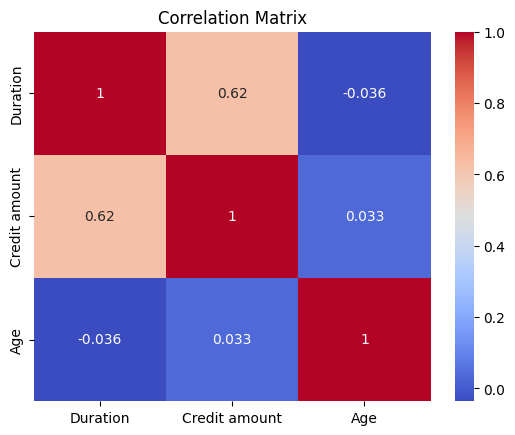

In [ ]:
corr = X_features[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
#gender based analysis
features_to_analyze = [
    'checking_status_string',
    'credit_history_string',
    'purpose_string',
    'savings_string',
    'employment_string',
    'other_guarantors_string',
    'property_string',
    'other_installment_string',
    'housing_string',
    'job_string',
    'marital_status',
    'has_guarantor',
    'is_unemployed',
    'has_telephone',
    'is_foreign',
    'has_other_debts',
    'Duration',
    'Credit amount',
    'Age'
]

fig = px.histogram(
    df_plot,
    x='gender',
    color='Creditability',
    barmode='group',
    title='Distribution of Creditability by Gender',
    labels={'gender': 'Gender', 'Creditability': ' (1: Good, 2: Bad)'}
)
fig.update_layout(xaxis_title='Gender', yaxis_title='Count')
fig.show()

for col in features_to_analyze:
  fig = px.histogram(
      df_plot,
      x=col,
      color='Creditability',
      facet_col='gender',
      barmode='group',
      title=f'Distribution of {col.replace("_", " ").title()} by Creditability and Gender',
      labels={col: col.replace('_', ' ').title(), 'Creditability': ' (1: Good, 2: Bad)', 'gender': 'Gender'}
  )
  fig.update_layout(xaxis_title=col.replace('_', ' ').title(), yaxis_title='Count')
  fig.show()

In [ ]:
import plotly.express as px

age_bins = [18, 25, 35, 45, 55, 65, 120]
age_labels = ['18–24', '25–34', '35–44', '45–54', '55–64', '65+']

df_plot['AgeGroup'] = pd.cut(df_plot['Age'], bins=age_bins, labels=age_labels, right=False)


fig = px.histogram(
    df_plot,
    x='AgeGroup',
    color='Creditability',
    barmode='group',
    title='<b>Creditability Distribution by Age Group</b>',
    labels={'AgeGroup': 'Age Group', 'Creditability': 'Creditability'},
    category_orders={'AgeGroup': age_labels}
)

fig.update_layout(
    xaxis_title='Age Group',
    yaxis_title='Count',
    bargap=0.2,
    template='plotly_white',
    legend_title_text='Creditability'
)
fig.show()

# -------------------------------

features_to_analyze_age_groups = [
    'checking_status_string', 'credit_history_string', 'purpose_string', 'savings_string',
    'employment_string', 'other_guarantors_string', 'property_string', 'other_installment_string',
    'housing_string', 'job_string', 'marital_status', 'gender', 'has_guarantor', 'is_unemployed',
    'has_telephone', 'is_foreign', 'has_other_debts', 'Duration', 'Credit amount'
]

for col in features_to_analyze_age_groups:
    fig = px.histogram(
        df_plot,
        x=col,
        color='Creditability',
        facet_col='AgeGroup',
        barmode='group',
        title=f'<b>Distribution of {col.replace("_", " ").title()} by Creditability and Age Group</b>',
        labels={
            col: col.replace('_', ' ').title(),
            'Creditability': 'Creditability',
            'AgeGroup': 'Age Group'
        },
        category_orders={'AgeGroup': age_labels}
    )

    fig.update_layout(
        xaxis_title=col.replace('_', ' ').title(),
        yaxis_title='Count',
        bargap=0.15,
        template='plotly_white',
        legend_title_text='Creditability'
    )
    fig.for_each_annotation(lambda a: a.update(text=a.text.replace("AgeGroup=", "")))  # Clean facet labels
    fig.show()


In [ ]:
fig = px.box(
    df_plot,
    x='job_string',
    y='Credit amount',
    color='Creditability',
    title='Credit Amount by Job and Creditability',
    labels={'job_string': 'Job', 'Credit amount': 'Credit Amount'}
)
fig.update_layout(xaxis_title='Job Category', yaxis_title='Credit Amount')
fig.show()

In [ ]:
job_dist = (
    df_plot.groupby(['job_string', 'Creditability'])
    .size()
    .reset_index(name='count')
)

job_dist['percent'] = (
    job_dist['count'] / job_dist.groupby('job_string')['count'].transform('sum')
) * 100

fig = px.bar(
    job_dist,
    x='job_string',
    y='percent',
    color='Creditability',
    barmode='group',
    title='Creditability Percentage by Job',
    labels={'job_string': 'Job', 'percent': 'Percentage'}
)
fig.update_layout(yaxis_tickformat='.1f')
fig.show()